### Pretraining on Unlabeled Data

In [1]:
import sys
from pathlib import Path
import torch
repo_root = Path.cwd().resolve().parents[1]
sys.path.insert(0, str(repo_root))
from BuildLLM.gpt import GPTModel




In [2]:
GPT_CONFIG_124M = {
    "vocab_size": 50257,
    "context_length": 256,
    "emb_dim" : 768,
    "n_heads" : 12,
    "n_layers" : 12,
    "drop_rate" : 0.1,
    # "drop_att_rate" : 0.1,
    # "drop_shortcut_rate" : 0.1,
    "qkv_bias" : False
}

In [3]:
torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
model.eval()

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(256, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=False)
        (W_key): Linear(in_features=768, out_features=768, bias=False)
        (W_value): Linear(in_features=768, out_features=768, bias=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features

In [4]:
import tiktoken
from BuildLLM.gpt import generate_text_simple

def text_to_token_ids(text, tokenizer):
    encoded = tokenizer.encode(text, allowed_special = {'<|endoftext|>'})
    encoded_tensor = torch.tensor(encoded).unsqueeze(0)
    return encoded_tensor

def token_ids_to_text(token_ids, tokenizer):
    flat = token_ids.squeeze(0)
    return tokenizer.decode(flat.tolist())

start_context = "Every effort moves you"
tokenizer = tiktoken.get_encoding("gpt2")

token_ids = generate_text_simple(
    model = model,
    idx = text_to_token_ids(start_context,tokenizer),
    max_new_tokens=10,
    context_size=GPT_CONFIG_124M["context_length"]
)

print("Output text: \n", token_ids_to_text(token_ids,tokenizer))


Output text: 
 Every effort moves you rentingetic wasnم refres RexMeCHicular stren


### Example to calculate text generation loss

In [5]:
inputs = torch.tensor([[16833, 3626, 6100],
                      [40,    1107, 588]])

targets = torch.tensor([[3626, 6100, 345],
                       [1107, 588, 11311]])


In [6]:
with torch.no_grad():
    logits = model(inputs)
probas = torch.softmax(logits, dim =-1)
print(probas.shape)
print("\n", probas)

torch.Size([2, 3, 50257])

 tensor([[[1.8849e-05, 1.5172e-05, 1.1687e-05,  ..., 2.2409e-05,
          6.9776e-06, 1.8776e-05],
         [9.1569e-06, 1.0062e-05, 7.8786e-06,  ..., 2.9090e-05,
          6.0103e-06, 1.3571e-05],
         [2.9877e-05, 8.8507e-06, 1.5741e-05,  ..., 3.5456e-05,
          1.4094e-05, 1.3526e-05]],

        [[1.2561e-05, 2.0537e-05, 1.4332e-05,  ..., 1.0389e-05,
          3.4784e-05, 1.4239e-05],
         [7.2731e-06, 1.7864e-05, 1.0565e-05,  ..., 2.1207e-05,
          1.1390e-05, 1.5559e-05],
         [2.9496e-05, 3.3605e-05, 4.1029e-05,  ..., 6.5249e-06,
          5.8203e-05, 1.3698e-05]]])


In [7]:
token_ids = torch.argmax(probas, dim =-1, keepdim =True)
print("Token IDs:\n", token_ids)

Token IDs:
 tensor([[[16657],
         [  339],
         [42826]],

        [[49906],
         [29669],
         [41751]]])


In [8]:
print(f"Targets batch 1:{token_ids_to_text(targets[0], tokenizer)}")
print(f"Outputs batch 1:{token_ids_to_text(token_ids[0].flatten(), tokenizer)}")


Targets batch 1: effort moves you
Outputs batch 1: Armed heNetflix


## here we calculate target probabilities

In [9]:
text_idx=0
target_probas_1 = probas[text_idx, [0,1,2],targets[text_idx]]
print("Text 1:", target_probas_1)

Text 1: tensor([7.4541e-05, 3.1061e-05, 1.1563e-05])


In [10]:
text_idx=1
target_probas_2 = probas[text_idx, [0,1,2],targets[text_idx]]
print("Text 2:", target_probas_2)

Text 2: tensor([1.0337e-05, 5.6776e-05, 4.7559e-06])


In [11]:
log_probas = torch.log(torch.cat((target_probas_1,target_probas_2)))
print(log_probas)

tensor([ -9.5042, -10.3796, -11.3677, -11.4798,  -9.7764, -12.2561])


In [12]:
avg_log_probas = torch.mean(log_probas)
print(avg_log_probas)

tensor(-10.7940)


In [13]:
neg_avg_log_probas = avg_log_probas * -1
print(neg_avg_log_probas)

tensor(10.7940)


In [14]:
print("logits shape", logits.shape)
print("targets shape", targets.shape)

logits shape torch.Size([2, 3, 50257])
targets shape torch.Size([2, 3])


In [15]:
logits_flat = logits.flatten(0,1)
targets_flat = targets.flatten()
print("Flattened logits : ", logits_flat.shape)
print("Flattened targets : ", targets_flat.shape)


Flattened logits :  torch.Size([6, 50257])
Flattened targets :  torch.Size([6])


In [16]:
loss= torch.nn.functional.cross_entropy(logits_flat, targets_flat)
print(loss)

tensor(10.7940)


In [17]:
perplexity = torch.exp(loss)
print(perplexity)

tensor(48725.8203)


## Loss calcualtion on dataset

In [18]:
file_path = "../the-verdict.txt"
with open(file_path,"r",encoding = "utf-8") as file:
    text_data = file.read()



In [19]:
total_characters =len(text_data)
total_tokens = len(tokenizer.encode(text_data))
print("Characters : ", total_characters)
print("total tokens : ",total_tokens)

Characters :  20479
total tokens :  5145


In [20]:
train_ratio= 0.9
split_idx = int(train_ratio * len(text_data))
train_data = text_data[:split_idx]
val_data = text_data[split_idx:]

In [21]:
train_characters =len(train_data)
train_tokens = len(tokenizer.encode(train_data))
print("Characters : ", train_characters)
print("total tokens : ",train_tokens)

Characters :  18431
total tokens :  4612


In [22]:
from BuildLLM.gpt import create_dataloader_v1
torch.manual_seed(123)

train_loader = create_dataloader_v1(
    train_data,
    batch_size=2,
    max_length=GPT_CONFIG_124M["context_length"],
    stride = GPT_CONFIG_124M["context_length"],
    drop_last= True,
    shuffle= True,
    num_workers= 0

)

val_loader = create_dataloader_v1(
    val_data,
    batch_size=2,
    max_length=GPT_CONFIG_124M["context_length"],
    stride = GPT_CONFIG_124M["context_length"],
    drop_last= False,
    shuffle= False,
    num_workers= 0

)



In [23]:
print("Train Loader:")
for x, y in train_loader:
    print(x.shape, y.shape)

print("\n Validation Loader:")
for x, y  in val_loader:
    print(x.shape, y.shape)

Train Loader:
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])

 Validation Loader:
torch.Size([2, 256]) torch.Size([2, 256])


In [24]:
def calc_loss_batch(input_batch, target_batch, model, device):
    input_batch = input_batch.to(device)
    target_batch = target_batch.to(device)
    logits = model(input_batch)
    loss = torch.nn.functional.cross_entropy(
        logits.flatten(0,1) , target_batch.flatten()
    )
    return loss

In [25]:
def calc_loss_loader(data_loader, model, device, num_batches = None):
    total_loss = 0
    if len(data_loader) == 0:
        return float("nan")
    elif num_batches is None:
        num_batches = len(data_loader)
    else:
        num_batches = min(num_batches, len(data_loader))
    
    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i < num_batches:
            loss = calc_loss_batch(
                input_batch , target_batch , model , device
            )
            total_loss += loss.item()
        else:
            break
    return total_loss/num_batches


In [26]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
with torch.no_grad():
    train_loss = calc_loss_loader(train_loader, model, device)
    val_loss = calc_loss_loader(val_loader, model, device)
print("Training Loss", train_loss)
print("Validation loss" ,val_loss)

Training Loss 10.987583690219456
Validation loss 10.981106758117676


## Traning an LLM

In [27]:
def train_model_simple(model, train_loader, val_loader, optimizer, 
                       device, num_epochs, eval_freq, eval_iter, start_context,tokenizer):
    train_losses, val_losses,track_tokens_seen = [], [], []
    tokens_seen, global_step = 0, -1
    for epoch in range(num_epochs):
        model.train()
        for input_batch, target_batch in train_loader:
            optimizer.zero_grad()
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            # print(loss)
            loss.backward()
            optimizer.step()
            tokens_seen += input_batch.numel()
            global_step += 1

            if global_step % eval_freq == 0:
                train_loss , val_loss = evaluate_model(
                    model, train_loader, val_loader, device, eval_iter
                )
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                track_tokens_seen.append(tokens_seen)
                print(f"Epoch {epoch+1}, Step {global_step:06d}, Tokens Seen: {tokens_seen}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")
        generated_text = generate_and_print_sample(
            model,
            tokenizer,
            device,
            start_context )
    return train_losses, val_losses, track_tokens_seen



In [28]:
def evaluate_model(model, train_loader, val_loader, device, eval_iter):
    model.eval()
    with torch.no_grad():
        train_loss = calc_loss_loader(train_loader, model, device, num_batches=eval_iter)
        val_loss = calc_loss_loader(val_loader, model, device, num_batches=eval_iter)
    model.train()
    return train_loss, val_loss

In [29]:
def generate_and_print_sample(model, tokenizer, device, start_context, max_new_tokens=20):
    model.eval()
    context_size = model.pos_emb.weight.shape[0]
    encoded = text_to_token_ids(start_context, tokenizer).to(device)
    with torch.no_grad():
        generated_ids = generate_text_simple(
            model=model,
            idx=encoded,
            max_new_tokens=50,
            context_size=context_size
        )
    decoded_text = token_ids_to_text(generated_ids, tokenizer)
    print(decoded_text.replace('\n',' '))
    model.train()

In [30]:
torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M).to(device)
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr =0.0004, weight_decay=0.1)
num_epochs = 10
train_losses, val_losses, track_tokens_seen = train_model_simple(
    model,
    train_loader,
    val_loader,
    optimizer,
    device,
    num_epochs= num_epochs,
    eval_freq= 5,
    eval_iter= 5,
    start_context= "Every Effort Moves You",
    tokenizer= tokenizer)

Epoch 1, Step 000000, Tokens Seen: 512, Train Loss: 9.7810, Val Loss: 9.9328
Epoch 1, Step 000005, Tokens Seen: 3072, Train Loss: 8.1105, Val Loss: 8.3386
Every Effort Moves You,,,,,,,,,,,.                                      
Epoch 2, Step 000010, Tokens Seen: 5632, Train Loss: 6.6609, Val Loss: 7.0480
Epoch 2, Step 000015, Tokens Seen: 8192, Train Loss: 5.9610, Val Loss: 6.6160
Every Effort Moves You, and, and, and, and,, and, and, and,, and,, and, and, and, and, and, and, and, and, and, and, and, and,, and, and, and
Epoch 3, Step 000020, Tokens Seen: 10752, Train Loss: 5.7261, Val Loss: 6.6004
Epoch 3, Step 000025, Tokens Seen: 13312, Train Loss: 5.2011, Val Loss: 6.3478
Every Effort Moves You to to the of the of the--I--I.                                      
Epoch 4, Step 000030, Tokens Seen: 15872, Train Loss: 4.4172, Val Loss: 6.2783
Epoch 4, Step 000035, Tokens Seen: 18432, Train Loss: 4.0687, Val Loss: 6.2258
Every Effort Moves You the                          "I he had the 

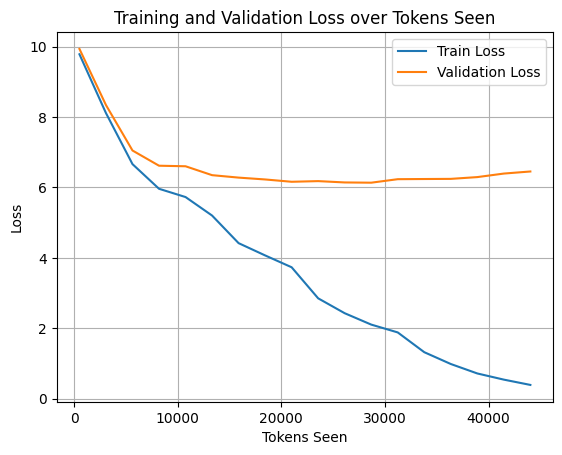

In [31]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

plt.plot(track_tokens_seen, train_losses, label = "Train Loss")
plt.plot(track_tokens_seen, val_losses, label = "Validation Loss")
plt.xlabel("Tokens Seen")
plt.ylabel("Loss")
plt.title("Training and Validation Loss over Tokens Seen")
plt.legend()
plt.grid()
plt.show()  

In [32]:
def plot_losses(epochs_seen, tokens_seen, train_losses, val_losses):
    fig, ax1 = plt.subplots(figsize=(5,3))
    ax1.plot(epochs_seen, train_losses, label = "Training Loss")
    ax1.plot(epochs_seen, val_losses, linestyle='--', label = "Validation Loss")
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Loss")
    ax1.legend(loc = "upper right")
    ax1.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax1.set_title("Training and Validation Loss over Epochs and tokens Seen")
    ax2 = ax1.twiny()
    ax2.plot(tokens_seen, train_losses, alpha=0)
    ax2.set_xlabel("Tokens Seen")
    plt.show()

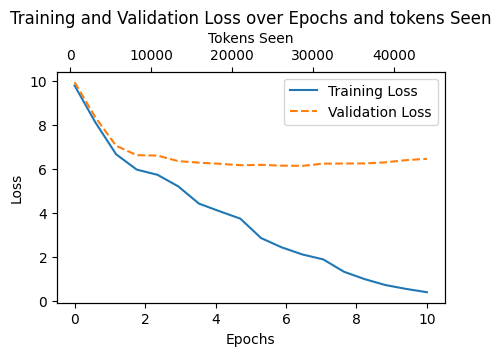

In [33]:
epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
plot_losses(epochs_tensor, track_tokens_seen, train_losses, val_losses)

## Decoding strategies

In [34]:
model.to("cpu")
model.eval()

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(256, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=False)
        (W_key): Linear(in_features=768, out_features=768, bias=False)
        (W_value): Linear(in_features=768, out_features=768, bias=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features

In [35]:
tokenizer = tiktoken.get_encoding("gpt2")
token_ids = generate_text_simple(
    model = model,
    idx = text_to_token_ids("Every effort moves you",tokenizer),
    max_new_tokens=25,
    context_size=GPT_CONFIG_124M["context_length"]
)
print("Output text: \n", token_ids_to_text(token_ids,tokenizer))

Output text: 
 Every effort moves you know," was one of the axioms he laid down across the Sevres and silver of an exquisitely appointed lun


In [36]:
vocab = {
    "closer" : 0,
    "every" : 1,
    "effort" : 2,
    "forward" : 3,
    "inches" : 4,
    "moves" : 5,
    "pizza" : 6,
    "toward" : 7,
    "you" : 8
}

In [37]:
inverse_vocab = {v : k for k, v in vocab.items()}

In [38]:
next_token_logits = torch.tensor(
    [4.51 , 0.89, -1.90, 6.75, 1.63, -1.62, -1.89, 6.28, 1.79]
)


In [39]:
probas  = torch.softmax(next_token_logits, dim = 0)
next_token_id = torch.argmax(probas).item()
print("Next token ID:", next_token_id)
print("Next token:", inverse_vocab[next_token_id])

Next token ID: 3
Next token: forward


In [40]:
torch.manual_seed(123)
next_token_id = torch.multinomial(probas, num_samples=1).item()
print("Sampled Next token ID:", next_token_id)
print("Sampled Next token:", inverse_vocab[next_token_id])

Sampled Next token ID: 3
Sampled Next token: forward


In [41]:
def print_sampled_tokens(probas):
    torch.manual_seed(123)
    sample = [torch.multinomial(probas, num_samples=1).item() for _ in range(1000)]
    sampled_ids = torch.bincount(torch.tensor(sample))
    for token_id, count in enumerate(sampled_ids):
        print(f"{inverse_vocab[token_id]} *  {count} with probabilities: {probas[token_id].item() * 100:.2f}%")
    

In [42]:
print_sampled_tokens(probas)

closer *  73 with probabilities: 6.09%
every *  0 with probabilities: 0.16%
effort *  0 with probabilities: 0.01%
forward *  582 with probabilities: 57.21%
inches *  2 with probabilities: 0.34%
moves *  0 with probabilities: 0.01%
pizza *  0 with probabilities: 0.01%
toward *  343 with probabilities: 35.76%


In [43]:
def softmax_with_temperature(logits, temperature):
    scaled_logits = logits/temperature
    return torch.softmax(scaled_logits, dim = 0)

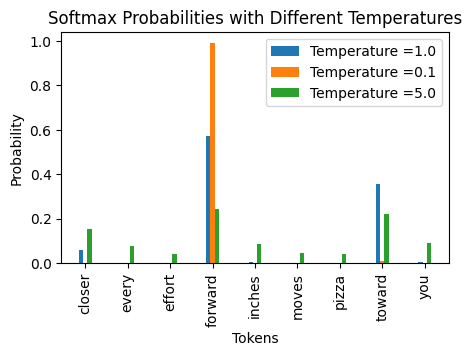

In [44]:
temperatures = [ 1.0, 0.1,5.0]
scaled_probas = [softmax_with_temperature(next_token_logits, temp) for temp in temperatures]
x = torch.arange(len(vocab))
bar_width = 0.1
fig, ax = plt.subplots(figsize=(5, 3))
for i, T in enumerate(temperatures):
    rects = ax.bar(x + i*bar_width, scaled_probas[i], width=bar_width, label=f"Temperature ={T}")
ax.set_xlabel("Tokens")
ax.set_ylabel("Probability")
ax.set_title("Softmax Probabilities with Different Temperatures")
ax.set_xticks(x + bar_width * (len(temperatures)-1) / 2)
ax.set_xticklabels(vocab.keys(), rotation = 90)
ax.legend()
plt.show()

In [45]:
scaled_probas

[tensor([6.0907e-02, 1.6313e-03, 1.0019e-04, 5.7212e-01, 3.4190e-03, 1.3257e-04,
         1.0120e-04, 3.5758e-01, 4.0122e-03]),
 tensor([1.8530e-10, 3.5189e-26, 2.6890e-38, 9.9099e-01, 5.7569e-23, 4.4220e-37,
         2.9718e-38, 9.0133e-03, 2.8514e-22]),
 tensor([0.1546, 0.0750, 0.0429, 0.2421, 0.0869, 0.0454, 0.0430, 0.2203, 0.0898])]

In [46]:
for i, p in enumerate(scaled_probas):
    print(f"\n-------Temperature: {temperatures[i]} -----------")
    print_sampled_tokens(p)
    


-------Temperature: 1.0 -----------
closer *  73 with probabilities: 6.09%
every *  0 with probabilities: 0.16%
effort *  0 with probabilities: 0.01%
forward *  582 with probabilities: 57.21%
inches *  2 with probabilities: 0.34%
moves *  0 with probabilities: 0.01%
pizza *  0 with probabilities: 0.01%
toward *  343 with probabilities: 35.76%

-------Temperature: 0.1 -----------
closer *  0 with probabilities: 0.00%
every *  0 with probabilities: 0.00%
effort *  0 with probabilities: 0.00%
forward *  985 with probabilities: 99.10%
inches *  0 with probabilities: 0.00%
moves *  0 with probabilities: 0.00%
pizza *  0 with probabilities: 0.00%
toward *  15 with probabilities: 0.90%

-------Temperature: 5.0 -----------
closer *  165 with probabilities: 15.46%
every *  75 with probabilities: 7.50%
effort *  42 with probabilities: 4.29%
forward *  239 with probabilities: 24.21%
inches *  71 with probabilities: 8.69%
moves *  46 with probabilities: 4.54%
pizza *  32 with probabilities: 4.30%

## top k sampling

In [47]:
top_k = 3
top_logits, top_pos = torch.topk(next_token_logits, top_k)
print("Top K Logits:", top_logits)
print("Top K Positions:", top_pos)

Top K Logits: tensor([6.7500, 6.2800, 4.5100])
Top K Positions: tensor([3, 7, 0])


In [48]:
new_logits = torch.where(
    condition = next_token_logits < top_logits[-1],
    input = torch.tensor(float("-inf")),
    other = next_token_logits
)
print("New Logits after Top-K Filtering:", new_logits)

New Logits after Top-K Filtering: tensor([4.5100,   -inf,   -inf, 6.7500,   -inf,   -inf,   -inf, 6.2800,   -inf])


In [49]:
top_k_probas = torch.softmax(new_logits, dim = 0)
print("Top-K Filtered Probabilities:", top_k_probas)


Top-K Filtered Probabilities: tensor([0.0615, 0.0000, 0.0000, 0.5775, 0.0000, 0.0000, 0.0000, 0.3610, 0.0000])


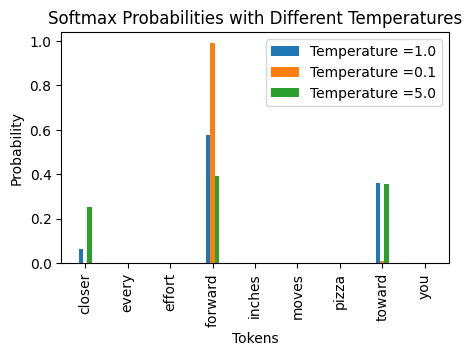

In [50]:
temperatures = [ 1.0, 0.1,5.0]
k_scaled_probas = [softmax_with_temperature(new_logits, temp) for temp in temperatures]
x = torch.arange(len(vocab))
bar_width = 0.1
fig, ax = plt.subplots(figsize=(5, 3))
for i, T in enumerate(temperatures):
    rects = ax.bar(x + i*bar_width, k_scaled_probas[i], width=bar_width, label=f"Temperature ={T}")
ax.set_xlabel("Tokens")
ax.set_ylabel("Probability")
ax.set_title("Softmax Probabilities with Different Temperatures")
ax.set_xticks(x + bar_width * (len(temperatures)-1) / 2)
ax.set_xticklabels(vocab.keys(), rotation = 90)
ax.legend()
plt.show()

In [51]:
for i, p in enumerate(k_scaled_probas):
    print(f"\n-------Temperature: {temperatures[i]} -----------")
    print_sampled_tokens(p)
        


-------Temperature: 1.0 -----------
closer *  73 with probabilities: 6.15%
every *  0 with probabilities: 0.00%
effort *  0 with probabilities: 0.00%
forward *  583 with probabilities: 57.75%
inches *  0 with probabilities: 0.00%
moves *  0 with probabilities: 0.00%
pizza *  0 with probabilities: 0.00%
toward *  344 with probabilities: 36.10%

-------Temperature: 0.1 -----------
closer *  0 with probabilities: 0.00%
every *  0 with probabilities: 0.00%
effort *  0 with probabilities: 0.00%
forward *  985 with probabilities: 99.10%
inches *  0 with probabilities: 0.00%
moves *  0 with probabilities: 0.00%
pizza *  0 with probabilities: 0.00%
toward *  15 with probabilities: 0.90%

-------Temperature: 5.0 -----------
closer *  258 with probabilities: 25.06%
every *  0 with probabilities: 0.00%
effort *  0 with probabilities: 0.00%
forward *  385 with probabilities: 39.23%
inches *  0 with probabilities: 0.00%
moves *  0 with probabilities: 0.00%
pizza *  0 with probabilities: 0.00%
towa

In [52]:
def generate(model, idx, max_new_tokens, context_size, temperature = 0.0, top_k = None, eos_id = None):
    for _ in range(max_new_tokens):
        idx_cond = idx[:, -context_size:]
        with torch.no_grad():
            logits = model(idx_cond)
        logits = logits[:, -1, :]

        if top_k is not None:   
            top_logits, _ = torch.topk(logits, top_k)
            min_val = top_logits[:,-1]
            logits = torch.where(
                logits < min_val,
                torch.tensor(float("-inf")).to(logits.device),
                logits
            )
        if temperature > 0.0:
            logits = logits/temperature
            probas = torch.softmax(logits, dim = -1)
            idx_next = torch.multinomial(probas, num_samples=1)
        else:
            idx_next = torch.argmax(logits, dim = -1, keepdim = True)
        if idx_next == eos_id:
            break
        idx = torch.cat((idx, idx_next), dim = 1)
    return idx

In [53]:
torch.manual_seed(123)
generated_ids = generate(
    model=model,
    idx=text_to_token_ids("Every effort moves you", tokenizer),
    max_new_tokens=15,
    context_size=GPT_CONFIG_124M["context_length"],
    temperature= 0.7,
    top_k= 25
)
print("Generated Text:\n", token_ids_to_text(generated_ids, tokenizer))

Generated Text:
 Every effort moves you know," was one of the axioms he laid down across the Sev


## Loading and saving weights in pytorch

In [54]:
torch.save(model.state_dict(), "model.pth")

In [55]:
model = GPTModel(GPT_CONFIG_124M)
model.load_state_dict(torch.load("model.pth", map_location=device))
model.eval()

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(256, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=False)
        (W_key): Linear(in_features=768, out_features=768, bias=False)
        (W_value): Linear(in_features=768, out_features=768, bias=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features

In [56]:
torch.save(
    {
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
    },
    "model_and_optimizer.pth"
)

In [57]:
checkpoint = torch.load("model_and_optimizer.pth")
model = GPTModel(GPT_CONFIG_124M)
model.load_state_dict(checkpoint["model_state_dict"])
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-4, weight_decay=0.1)
optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
model.train()

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(256, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=False)
        (W_key): Linear(in_features=768, out_features=768, bias=False)
        (W_value): Linear(in_features=768, out_features=768, bias=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features

## loading weights from openAI

In [58]:
import urllib.request
url = ("https://raw.githubusercontent.com/rasbt/LLMs-from-scratch/main/ch05/01_main-chapter-code/gpt_download.py")
filename = url.split('/')[-1]
urllib.request.urlretrieve(url, filename)

('gpt_download.py', <http.client.HTTPMessage at 0x11aa93b90>)

In [59]:
from gpt_download import download_and_load_gpt2
settings, params = download_and_load_gpt2(
    model_size = "124M", models_dir = "gpt2"
)

checkpoint: 100%|██████████| 77.0/77.0 [00:00<00:00, 55.2kiB/s]
encoder.json: 100%|██████████| 1.04M/1.04M [00:00<00:00, 2.14MiB/s]
hparams.json: 100%|██████████| 90.0/90.0 [00:00<00:00, 87.9kiB/s]
model.ckpt.data-00000-of-00001: 100%|██████████| 498M/498M [02:45<00:00, 3.02MiB/s]  
model.ckpt.index: 100%|██████████| 5.21k/5.21k [00:00<00:00, 3.67MiB/s]
model.ckpt.meta: 100%|██████████| 471k/471k [00:00<00:00, 1.44MiB/s]
vocab.bpe: 100%|██████████| 456k/456k [00:00<00:00, 1.43MiB/s]


In [61]:
print("Settings", settings)
print("Model Parameters", params.keys())

Settings {'n_vocab': 50257, 'n_ctx': 1024, 'n_embd': 768, 'n_head': 12, 'n_layer': 12}
Model Parameters dict_keys(['blocks', 'b', 'g', 'wpe', 'wte'])


In [64]:
print(params["wte"])
print("Token embedding weight tensor dimensions:", params["wte"].shape)

[[-0.11010301 -0.03926672  0.03310751 ... -0.1363697   0.01506208
   0.04531523]
 [ 0.04034033 -0.04861503  0.04624869 ...  0.08605453  0.00253983
   0.04318958]
 [-0.12746179  0.04793796  0.18410145 ...  0.08991534 -0.12972379
  -0.08785918]
 ...
 [-0.04453601 -0.05483596  0.01225674 ...  0.10435229  0.09783269
  -0.06952604]
 [ 0.1860082   0.01665728  0.04611587 ... -0.09625227  0.07847701
  -0.02245961]
 [ 0.05135201 -0.02768905  0.0499369  ...  0.00704835  0.15519823
   0.12067825]]
Token embedding weight tensor dimensions: (50257, 768)


In [84]:
print(params["blocks"][0]["mlp"].keys())

dict_keys(['c_fc', 'c_proj'])


In [108]:
model_configs = {
    "gpt2-small (124M)": {"emb_dim":768, "n_layers" : 12, "n_heads":12},
    "gpt2-medium (355M)": {"emb_dim":1024, "n_layers":24, "n_heads":16},
    "gpt2-large (774M)": {"emb_dim":1280, "n_layers":36, "n_heads":20},
    "gpt2-xl (1558M)": {"emb_dim":1600, "n_layers":48, "n_heads":25}
}

In [109]:
model_name = "gpt2-small (124M)"
NEW_CONFIG = GPT_CONFIG_124M.copy()
NEW_CONFIG.update(model_configs[model_name])
NEW_CONFIG.update({"context_length": 1024})
NEW_CONFIG.update({"qkv_bias": True})
print("Updated Config:", NEW_CONFIG)    

Updated Config: {'vocab_size': 50257, 'context_length': 1024, 'emb_dim': 768, 'n_heads': 12, 'n_layers': 12, 'drop_rate': 0.1, 'qkv_bias': True}


In [110]:
gpt = GPTModel(NEW_CONFIG)
gpt.eval()

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=True)
        (W_key): Linear(in_features=768, out_features=768, bias=True)
        (W_value): Linear(in_features=768, out_features=768, bias=True)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=7

In [111]:
def assign(left, right):
    if left.shape != right.shape:
        raise ValueError(f"Shape mismatch: left {left.shape} vs right {right.shape}")
    return torch.nn.Parameter(torch.tensor(right))

In [112]:
import numpy as np
def load_weights_into_gpt(gpt, params):
    gpt.pos_emb.weight = assign(gpt.pos_emb.weight, params["wpe"])
    gpt.tok_emb.weight = assign(gpt.tok_emb.weight, params["wte"])

    for b in range(len(params["blocks"])):
        q_w, k_w, v_w = np.split(
            (params["blocks"][b]["attn"]["c_attn"])["w"], 3, axis =1)
        gpt.trf_blocks[b].att.W_query.weight = assign(gpt.trf_blocks[b].att.W_query.weight, q_w.T)
        gpt.trf_blocks[b].att.W_key.weight = assign(gpt.trf_blocks[b].att.W_key.weight, k_w.T)
        gpt.trf_blocks[b].att.W_value.weight = assign(gpt.trf_blocks[b].att.W_value.weight, v_w.T)

        q_b, k_b, v_b = np.split(
            (params["blocks"][b]["attn"]["c_attn"])["b"], 3, axis =-1)
        gpt.trf_blocks[b].att.W_query.bias = assign(gpt.trf_blocks[b].att.W_query.bias, q_b)
        gpt.trf_blocks[b].att.W_key.bias = assign(gpt.trf_blocks[b].att.W_key.bias, k_b)
        gpt.trf_blocks[b].att.W_value.bias = assign(gpt.trf_blocks[b].att.W_value.bias, v_b)

        gpt.trf_blocks[b].att.out_proj.weight = assign(
            gpt.trf_blocks[b].att.out_proj.weight, params["blocks"][b]["attn"]["c_proj"]["w"].T)
        
        gpt.trf_blocks[b].att.out_proj.bias = assign(
            gpt.trf_blocks[b].att.out_proj.bias, params["blocks"][b]["attn"]["c_proj"]["b"])
        
        gpt.trf_blocks[b].ff.layers[0].weight = assign(
            gpt.trf_blocks[b].ff.layers[0].weight, params["blocks"][b]["mlp"]["c_fc"]["w"].T)
        gpt.trf_blocks[b].ff.layers[0].bias = assign(
            gpt.trf_blocks[b].ff.layers[0].bias, params["blocks"][b]["mlp"]["c_fc"]["b"])
        gpt.trf_blocks[b].ff.layers[2].weight = assign(
            gpt.trf_blocks[b].ff.layers[2].weight, params["blocks"][b]["mlp"]["c_proj"]["w"].T)
        gpt.trf_blocks[b].ff.layers[2].bias = assign(
            gpt.trf_blocks[b].ff.layers[2].bias, params["blocks"][b]["mlp"]["c_proj"]["b"])
        

        gpt.trf_blocks[b].norm1.scale = assign(
            gpt.trf_blocks[b].norm1.scale,
            params["blocks"][b]["ln_1"]["g"])
        
        gpt.trf_blocks[b].norm1.shift = assign(
            gpt.trf_blocks[b].norm1.shift,
            params["blocks"][b]["ln_1"]["b"])
        
        gpt.trf_blocks[b].norm2.scale = assign(
            gpt.trf_blocks[b].norm2.scale,
            params["blocks"][b]["ln_2"]["g"])   
        
        gpt.trf_blocks[b].norm2.shift = assign(
            gpt.trf_blocks[b].norm2.shift,
            params["blocks"][b]["ln_2"]["b"])
        
        gpt.final_norm.scale = assign(gpt.final_norm.scale, params["g"])
        gpt.final_norm.shift = assign(gpt.final_norm.shift, params["b"])
        gpt.out_head.weight = assign(gpt.out_head.weight, params["wte"])



In [113]:
load_weights_into_gpt(gpt, params)
gpt.to(device)

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=True)
        (W_key): Linear(in_features=768, out_features=768, bias=True)
        (W_value): Linear(in_features=768, out_features=768, bias=True)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=7

In [114]:
torch.manual_seed(123)
token_ids = generate(
    model= gpt,
    idx = text_to_token_ids("Every effort moves you", tokenizer).to(device),
    max_new_tokens=25,
    context_size=NEW_CONFIG["context_length"],
    temperature= 1.5,
    top_k= 50
)
print("Generated Text:\n", token_ids_to_text(token_ids, tokenizer))

Generated Text:
 Every effort moves you toward finding an ideal new way to practice something!

What makes us want to be on top of that?




In [119]:
with torch.no_grad():
    train_loss = calc_loss_loader(train_loader, gpt, device)
    val_loss = calc_loss_loader(val_loader, gpt, device)
print("Training Loss", train_loss)
print("Validation loss" ,val_loss)

Training Loss 3.7547330061594644
Validation loss 3.5596015453338623


## 1558M parameters

In [121]:
hparams, params = download_and_load_gpt2(model_size = "1558M", models_dir = "gpt2")
print("Hyperparameters:", hparams)
print("Model Parameters:", params.keys())

checkpoint: 100%|██████████| 77.0/77.0 [00:00<00:00, 56.6kiB/s]
encoder.json: 100%|██████████| 1.04M/1.04M [00:00<00:00, 2.67MiB/s]
hparams.json: 100%|██████████| 91.0/91.0 [00:00<00:00, 72.4kiB/s]
model.ckpt.data-00000-of-00001: 100%|██████████| 6.23G/6.23G [47:53<00:00, 2.17MiB/s]  
model.ckpt.index: 100%|██████████| 20.7k/20.7k [00:00<00:00, 124kiB/s]
model.ckpt.meta: 100%|██████████| 1.84M/1.84M [00:00<00:00, 1.99MiB/s]
vocab.bpe: 100%|██████████| 456k/456k [00:00<00:00, 1.44MiB/s]


Hyperparameters: {'n_vocab': 50257, 'n_ctx': 1024, 'n_embd': 1600, 'n_head': 25, 'n_layer': 48}
Model Parameters: dict_keys(['blocks', 'b', 'g', 'wpe', 'wte'])


In [122]:
GPT_CONFIG_XL = {
    "vocab_size": 50257,
    "context_length": 1024,
    "emb_dim" : 1600,
    "n_heads" : 25,
    "n_layers" : 48,
    "drop_rate" : 0.1,
    "qkv_bias" : False
}

In [123]:
model_name = "gpt2-xl (1558M)"
NEW_CONFIG = GPT_CONFIG_XL.copy()
NEW_CONFIG.update(model_configs[model_name])
NEW_CONFIG.update({"context_length": 1024})
NEW_CONFIG.update({"qkv_bias": True})
print("Updated Config:", NEW_CONFIG) 

Updated Config: {'vocab_size': 50257, 'context_length': 1024, 'emb_dim': 1600, 'n_heads': 25, 'n_layers': 48, 'drop_rate': 0.1, 'qkv_bias': True}


In [124]:
gpt = GPTModel(NEW_CONFIG)
gpt.eval()

GPTModel(
  (tok_emb): Embedding(50257, 1600)
  (pos_emb): Embedding(1024, 1600)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=1600, out_features=1600, bias=True)
        (W_key): Linear(in_features=1600, out_features=1600, bias=True)
        (W_value): Linear(in_features=1600, out_features=1600, bias=True)
        (out_proj): Linear(in_features=1600, out_features=1600, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=1600, out_features=6400, bias=True)
          (1): GELU()
          (2): Linear(in_features=6400, out_features=1600, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(i

In [125]:
load_weights_into_gpt(gpt, params)
gpt.to(device)

GPTModel(
  (tok_emb): Embedding(50257, 1600)
  (pos_emb): Embedding(1024, 1600)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=1600, out_features=1600, bias=True)
        (W_key): Linear(in_features=1600, out_features=1600, bias=True)
        (W_value): Linear(in_features=1600, out_features=1600, bias=True)
        (out_proj): Linear(in_features=1600, out_features=1600, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=1600, out_features=6400, bias=True)
          (1): GELU()
          (2): Linear(in_features=6400, out_features=1600, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(i

In [126]:
torch.manual_seed(123)
token_ids = generate(
    model= gpt,
    idx = text_to_token_ids("Every effort moves you", tokenizer).to(device),
    max_new_tokens=25,
    context_size=NEW_CONFIG["context_length"],
    temperature= 1.5,
    top_k= 50
)
print("Generated Text:\n", token_ids_to_text(token_ids, tokenizer))

Generated Text:
 Every effort moves you toward finding an ideal life. You don't have to accept your current one at once, because if you do you'll never


In [127]:
with torch.no_grad():
    train_loss = calc_loss_loader(train_loader, gpt, device)
    val_loss = calc_loss_loader(val_loader, gpt, device)
print("Training Loss", train_loss)
print("Validation loss" ,val_loss)

Training Loss 3.3046097490522595
Validation loss 3.1194920539855957


In [128]:
import shutil
import os

model_dir = "gpt2/1558M"

if os.path.exists(model_dir):
    confirm = input(f"Are you sure you want to delete {model_dir}? (yes/no): ")
    if confirm.lower() == "yes":
        shutil.rmtree(model_dir)
        print("Deleted successfully.")
    else:
        print("Deletion cancelled.")
else:
    print("Directory not found.")

: 